<a href="https://colab.research.google.com/github/Nicolasvc9/Accidents_Barranquilla/blob/main/Accidents_barranquilla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
url="/content/drive/MyDrive/Diplomado/Accidents_Barranquilla.csv"
df=pd.read_csv(url)
print(df.head())

  HORA_ACCIDENTE GRAVEDAD_ACCIDENTE CLASE_ACCIDENTE  \
0    01:30:00:am        Con heridos       Atropello   
1    02:00:00:pm         Solo daños          Choque   
2    04:00:00:am         Solo daños          Choque   
3    04:30:00:am         Solo daños          Choque   
4    05:20:00:pm         Solo daños          Choque   

   CANT_HERIDOS_EN _SITIO_ACCIDENTE  CANT_MUERTOS_EN _SITIO_ACCIDENTE  \
0                               1.0                               NaN   
1                               NaN                               NaN   
2                               NaN                               NaN   
3                               NaN                               NaN   
4                               NaN                               NaN   

   AÑO_ACCIDENTE MES_ACCIDENTE DIA_ACCIDENTE  
0           2018       January           Mon  
1           2018       January           Mon  
2           2018       January           Mon  
3           2018       January           M

In [ ]:
# Asegurar que la columna es de tipo string
df['HORA_ACCIDENTE'] = df['HORA_ACCIDENTE'].astype(str)

# Corregir el formato eliminando el segundo ':'
df['HORA_ACCIDENTE'] = df['HORA_ACCIDENTE'].str.replace(r'(\d{2}:\d{2}:\d{2}):([ap]m)', r'\1 \2', regex=True)

# Convertir a formato 24 horas
df['HORA_ACCIDENTE'] = pd.to_datetime(df['HORA_ACCIDENTE'], format='%I:%M:%S %p', errors='coerce').dt.hour



# Ver si hay valores NaN después de la conversión (indicando datos mal formateados)
print(df[df['HORA_ACCIDENTE'].isna()])


       HORA_ACCIDENTE GRAVEDAD_ACCIDENTE CLASE_ACCIDENTE  \
0                 NaN        Con heridos       Atropello   
1                 NaN         Solo daños          Choque   
2                 NaN         Solo daños          Choque   
3                 NaN         Solo daños          Choque   
4                 NaN         Solo daños          Choque   
...               ...                ...             ...   
26224             NaN        Con heridos          Choque   
26225             NaN        Con heridos          Choque   
26226             NaN        Con heridos          Choque   
26227             NaN        Con heridos          Choque   
26228             NaN        Con heridos          Choque   

       CANT_HERIDOS_EN _SITIO_ACCIDENTE  CANT_MUERTOS_EN _SITIO_ACCIDENTE  \
0                                   1.0                               NaN   
1                                   NaN                               NaN   
2                                   NaN         

MAE: 0.2659005967863115
RMSE: 0.7343493641438812


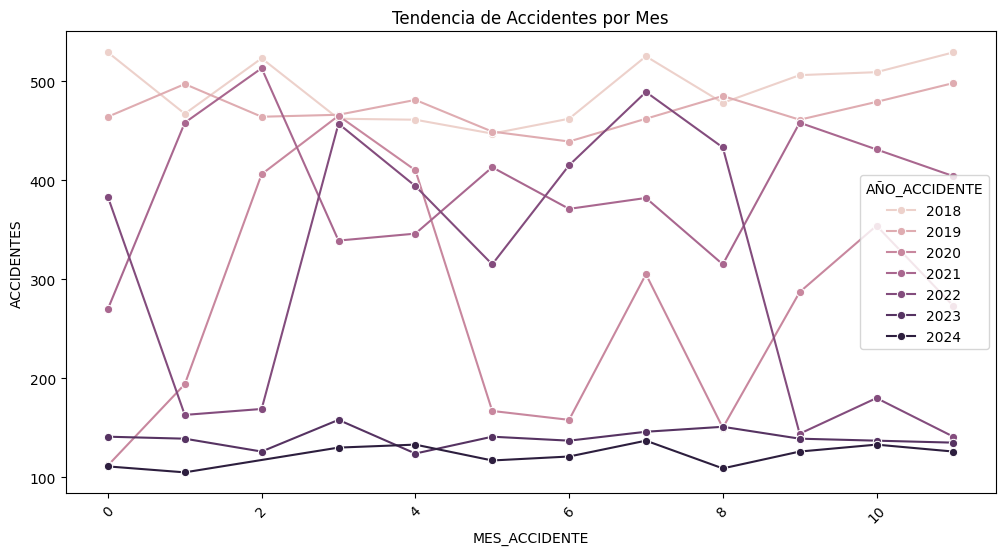

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

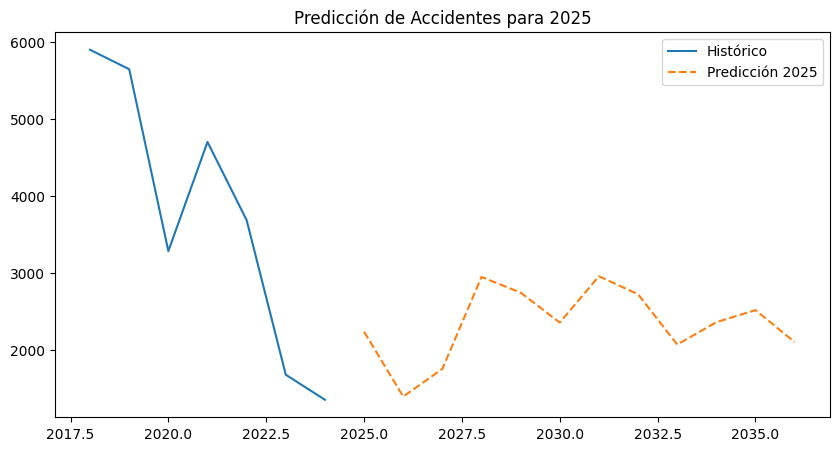

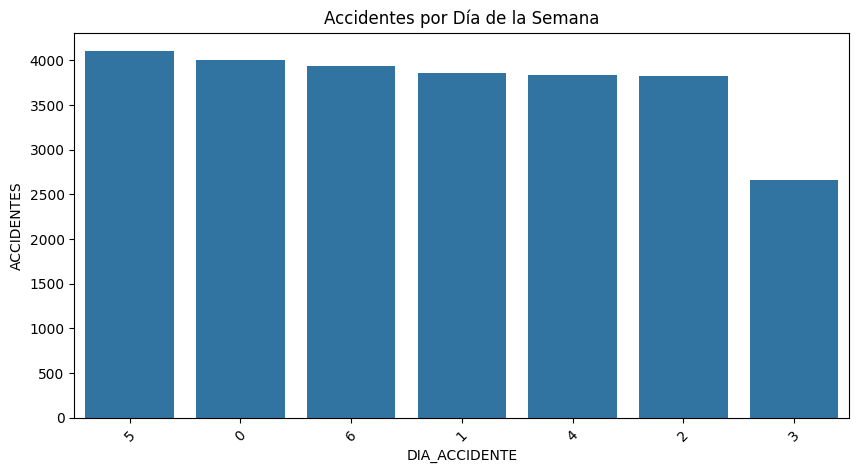

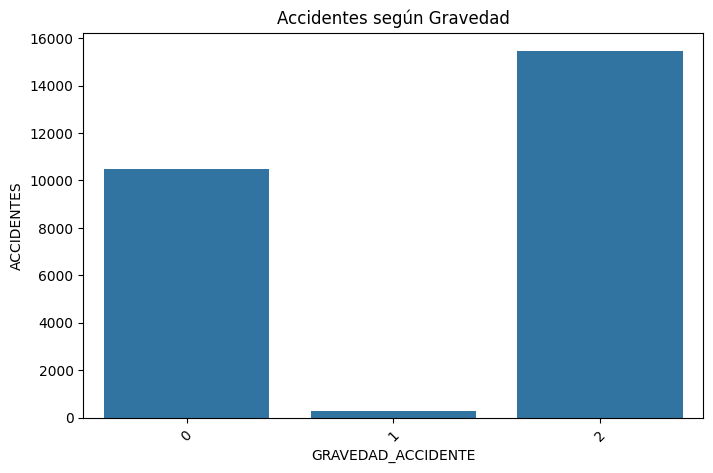

In [ ]:
# Asegurar que la columna HORA_ACCIDENTE es string y corregir formato
df['HORA_ACCIDENTE'] = df['HORA_ACCIDENTE'].astype(str)
df['HORA_ACCIDENTE'] = df['HORA_ACCIDENTE'].str.replace(r'(\d{2}:\d{2}:\d{2}):([ap]m)', r'\1 \2', regex=True)
df['HORA_ACCIDENTE'] = pd.to_datetime(df['HORA_ACCIDENTE'], format='%I:%M:%S %p', errors='coerce').dt.hour

# Codificación de variables categóricas
encoder = LabelEncoder()
categoricas = ['GRAVEDAD_ACCIDENTE', 'CLASE_ACCIDENTE', 'MES_ACCIDENTE', 'DIA_ACCIDENTE']
for col in categoricas:
    df[col] = encoder.fit_transform(df[col])

# Definir variables de entrada y salida
X = df[['HORA_ACCIDENTE', 'GRAVEDAD_ACCIDENTE', 'CLASE_ACCIDENTE', 'MES_ACCIDENTE', 'DIA_ACCIDENTE', 'AÑO_ACCIDENTE']]
y_accidentes = df[['CANT_HERIDOS_EN _SITIO_ACCIDENTE', 'CANT_MUERTOS_EN _SITIO_ACCIDENTE']].sum(axis=1)

# División de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_accidentes, test_size=0.2, random_state=42)

# Modelo de regresión para predecir tasa de accidentabilidad
modelo = RandomForestRegressor(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# Predicciones y evaluación
y_pred = modelo.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}')

# Predicción para el 2025
X_2025 = X[X['AÑO_ACCIDENTE'] == 2024].copy()
X_2025['AÑO_ACCIDENTE'] = 2025
y_2025_pred = modelo.predict(X_2025)

# Visualización de tendencias
df_agg = df.groupby(['AÑO_ACCIDENTE', 'MES_ACCIDENTE']).size().reset_index(name='ACCIDENTES')
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_agg, x='MES_ACCIDENTE', y='ACCIDENTES', hue='AÑO_ACCIDENTE', marker='o')
plt.title('Tendencia de Accidentes por Mes')
plt.xticks(rotation=45)
plt.show()

# Modelo ARIMA para series temporales
df_time = df.groupby('AÑO_ACCIDENTE').size()
modelo_arima = ARIMA(df_time, order=(5,1,0))
modelo_arima_fit = modelo_arima.fit()
pred_arima = modelo_arima_fit.forecast(steps=12)

plt.figure(figsize=(10, 5))
plt.plot(df_time, label='Histórico')
plt.plot(range(2025, 2025+len(pred_arima)), pred_arima, label='Predicción 2025', linestyle='--')
plt.legend()
plt.title('Predicción de Accidentes para 2025')
plt.show()

# Análisis de días pico de accidentabilidad
df_pico = df.groupby('DIA_ACCIDENTE').size().reset_index(name='ACCIDENTES')
plt.figure(figsize=(10, 5))
sns.barplot(data=df_pico, x='DIA_ACCIDENTE', y='ACCIDENTES', order=df_pico.sort_values('ACCIDENTES', ascending=False)['DIA_ACCIDENTE'])
plt.title('Accidentes por Día de la Semana')
plt.xticks(rotation=45)
plt.show()

# Gráfico de tasa de accidentes según gravedad
df_gravedad = df.groupby('GRAVEDAD_ACCIDENTE').size().reset_index(name='ACCIDENTES')
plt.figure(figsize=(8, 5))
sns.barplot(data=df_gravedad, x='GRAVEDAD_ACCIDENTE', y='ACCIDENTES')
plt.title('Accidentes según Gravedad')
plt.xticks(rotation=45)
plt.show()

Model MAE: 0.2659005967863115
Model RMSE: 0.7343493641438812
Baseline MAE: 0.7168305046753805
Baseline RMSE: 1.0115103916880752
MAE Improvement: 62.91%
RMSE Improvement: 27.40%


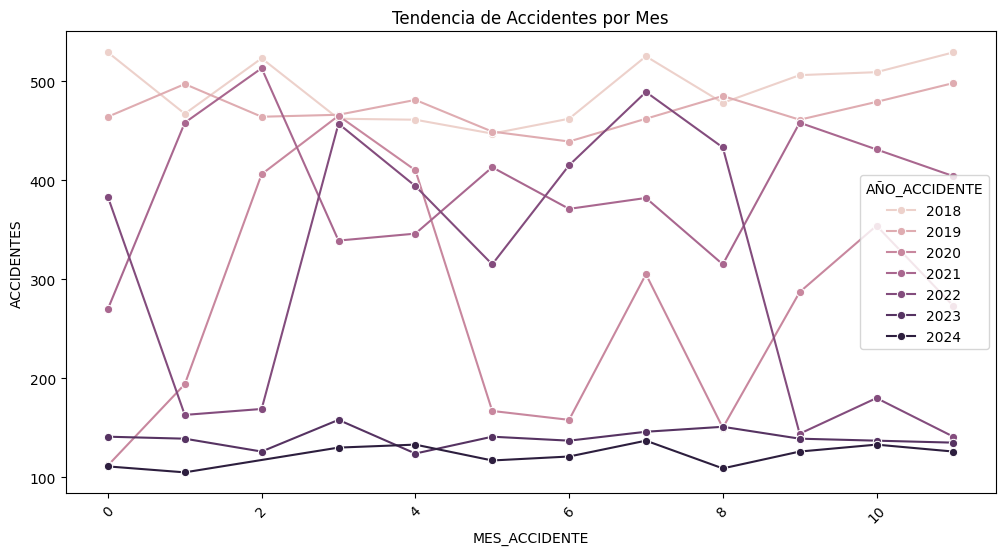

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

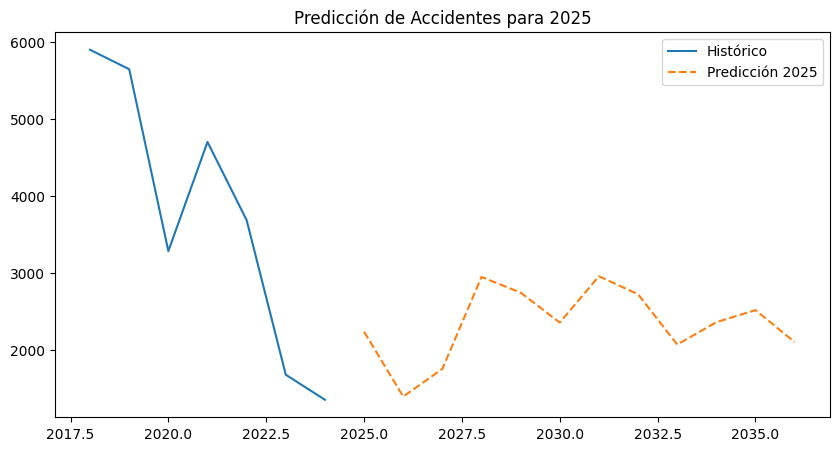

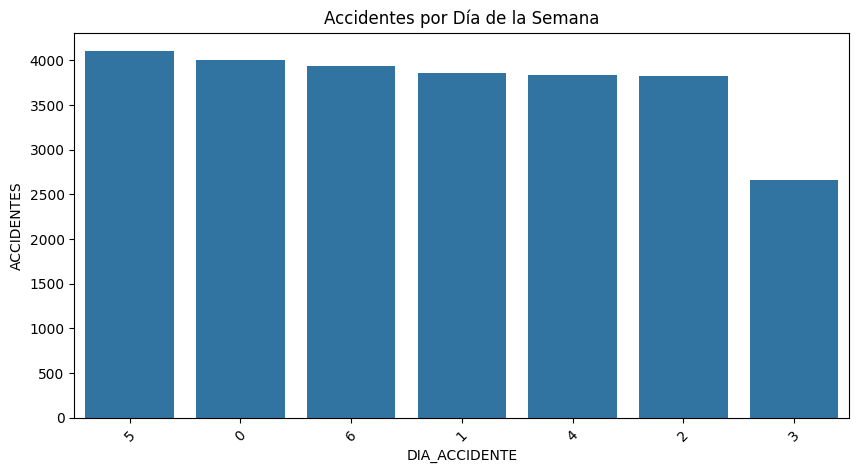

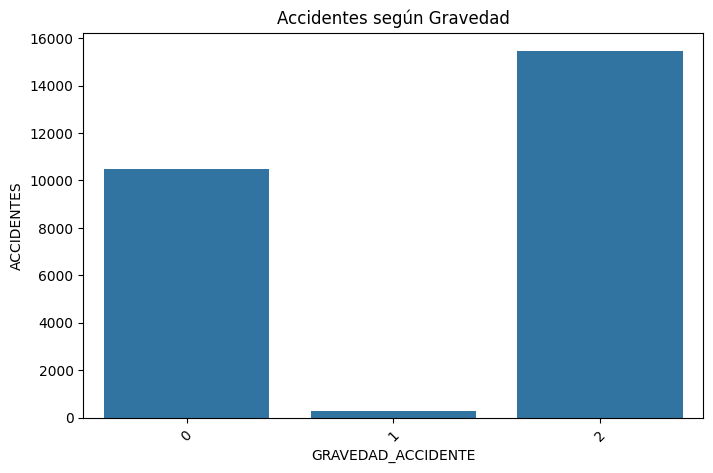

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

# Asegurar que la columna HORA_ACCIDENTE es string y corregir formato
df['HORA_ACCIDENTE'] = df['HORA_ACCIDENTE'].astype(str)
df['HORA_ACCIDENTE'] = df['HORA_ACCIDENTE'].str.replace(r'(\d{2}:\d{2}:\d{2}):([ap]m)', r'\1 \2', regex=True)
df['HORA_ACCIDENTE'] = pd.to_datetime(df['HORA_ACCIDENTE'], format='%I:%M:%S %p', errors='coerce').dt.hour

# Codificación de variables categóricas
encoder = LabelEncoder()
categoricas = ['GRAVEDAD_ACCIDENTE', 'CLASE_ACCIDENTE', 'MES_ACCIDENTE', 'DIA_ACCIDENTE']
for col in categoricas:
    df[col] = encoder.fit_transform(df[col])

# Definir variables de entrada y salida
X = df[['HORA_ACCIDENTE', 'GRAVEDAD_ACCIDENTE', 'CLASE_ACCIDENTE', 'MES_ACCIDENTE', 'DIA_ACCIDENTE', 'AÑO_ACCIDENTE']]
y_accidentes = df[['CANT_HERIDOS_EN _SITIO_ACCIDENTE', 'CANT_MUERTOS_EN _SITIO_ACCIDENTE']].sum(axis=1)

# División de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_accidentes, test_size=0.2, random_state=42)

# Modelo de regresión para predecir tasa de accidentabilidad
modelo = RandomForestRegressor(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# Predicciones y evaluación
y_pred = modelo.predict(X_test)
mae_model = mean_absolute_error(y_test, y_pred)
rmse_model = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Model MAE: {mae_model}')
print(f'Model RMSE: {rmse_model}')

# Baseline: predicción usando la media de y_train
y_baseline = np.full_like(y_test, y_train.mean())
mae_baseline = mean_absolute_error(y_test, y_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_baseline))
print(f'Baseline MAE: {mae_baseline}')
print(f'Baseline RMSE: {rmse_baseline}')

# Comparación de errores
print(f'MAE Improvement: {(mae_baseline - mae_model) / mae_baseline * 100:.2f}%')
print(f'RMSE Improvement: {(rmse_baseline - rmse_model) / rmse_baseline * 100:.2f}%')

# Predicción para el 2025
X_2025 = X[X['AÑO_ACCIDENTE'] == 2024].copy()
X_2025['AÑO_ACCIDENTE'] = 2025
y_2025_pred = modelo.predict(X_2025)

# Visualización de tendencias
df_agg = df.groupby(['AÑO_ACCIDENTE', 'MES_ACCIDENTE']).size().reset_index(name='ACCIDENTES')
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_agg, x='MES_ACCIDENTE', y='ACCIDENTES', hue='AÑO_ACCIDENTE', marker='o')
plt.title('Tendencia de Accidentes por Mes')
plt.xticks(rotation=45)
plt.show()

# Modelo ARIMA para series temporales
df_time = df.groupby('AÑO_ACCIDENTE').size()
modelo_arima = ARIMA(df_time, order=(5,1,0))
modelo_arima_fit = modelo_arima.fit()
pred_arima = modelo_arima_fit.forecast(steps=12)

plt.figure(figsize=(10, 5))
plt.plot(df_time, label='Histórico')
plt.plot(range(2025, 2025+len(pred_arima)), pred_arima, label='Predicción 2025', linestyle='--')
plt.legend()
plt.title('Predicción de Accidentes para 2025')
plt.show()

# Análisis de días pico de accidentabilidad
df_pico = df.groupby('DIA_ACCIDENTE').size().reset_index(name='ACCIDENTES')
plt.figure(figsize=(10, 5))
sns.barplot(data=df_pico, x='DIA_ACCIDENTE', y='ACCIDENTES', order=df_pico.sort_values('ACCIDENTES', ascending=False)['DIA_ACCIDENTE'])
plt.title('Accidentes por Día de la Semana')
plt.xticks(rotation=45)
plt.show()

# Gráfico de tasa de accidentes según gravedad
df_gravedad = df.groupby('GRAVEDAD_ACCIDENTE').size().reset_index(name='ACCIDENTES')
plt.figure(figsize=(8, 5))
sns.barplot(data=df_gravedad, x='GRAVEDAD_ACCIDENTE', y='ACCIDENTES')
plt.title('Accidentes según Gravedad')
plt.xticks(rotation=45)
plt.show()
